In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import time
import copy

# ==========================================
# 1. CENTRAL CONFIGURATION
# ==========================================
CONFIG = {
    # Data params
    "num_genes": 16241,      # <-- Updated to your exact gene count!
    "use_test_set": False,   # False = 80/20 Train/Val. True = 70/15/15 Train/Val/Test
    "batch_size": 64,        # Increased because you have 2 GPUs
    
    # Model params
    "embed_dim": 128,
    "num_heads": 4,
    "num_layers": 3,
    "cnn_kernel_stride": 16, # Compression factor
    
    # Training params
    "epochs": 50,
    "lr": 0.0005,
    "weight_decay": 0.01,
    "patience": 5,           # Early stopping patience
    "lr_factor": 0.5,        # LR scheduler reduction factor
    "lr_patience": 2         # LR scheduler patience
}

# ==========================================
# 2. HARDWARE SETUP (Dual T4 GPU)
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Primary Device: {device}")

if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"GPUs Detected: {num_gpus}")
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Primary Device: cuda
GPUs Detected: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [2]:
print("Loading Parquet files...")
mrna_df = pd.read_parquet('/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/mrna_final.parquet')
cnv_df = pd.read_parquet('/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/cnv_final.parquet')
mut_df = pd.read_parquet('/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/mut_final.parquet')
labels_df = pd.read_parquet('/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/labels_final.parquet')

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels_df['_primary_disease'])
CONFIG["num_classes"] = len(le.classes_)

# Flexible Train/Val/Test Split
indices = np.arange(len(y))

if CONFIG["use_test_set"]:
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=y, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=42)
    print(f"Split: Train={len(train_idx)} | Val={len(val_idx)} | Test={len(test_idx)}")
else:
    train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=y, random_state=42)
    test_idx = None
    print(f"Split: Train={len(train_idx)} | Val={len(val_idx)} | No Test Set")

class MultiOmicsDataset(Dataset):
    def __init__(self, mrna, cnv, mut, labels, indices):
        self.x = torch.tensor(
            np.stack([
                mrna.iloc[indices].values, 
                cnv.iloc[indices].values, 
                mut.iloc[indices].values
            ], axis=-1), dtype=torch.float32
        )
        self.y = torch.tensor(labels[indices], dtype=torch.long)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

# Create DataLoaders
train_loader = DataLoader(MultiOmicsDataset(mrna_df, cnv_df, mut_df, y, train_idx), batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(MultiOmicsDataset(mrna_df, cnv_df, mut_df, y, val_idx), batch_size=CONFIG["batch_size"], shuffle=False)

if CONFIG["use_test_set"]:
    test_loader = DataLoader(MultiOmicsDataset(mrna_df, cnv_df, mut_df, y, test_idx), batch_size=CONFIG["batch_size"], shuffle=False)

Loading Parquet files...
Split: Train=6580 | Val=1645 | No Test Set


In [3]:
class OncoBridgePhase1(nn.Module):
    def __init__(self, config):
        super(OncoBridgePhase1, self).__init__()
        
        embed_dim = config["embed_dim"]
        k_s = config["cnn_kernel_stride"]
        
        # 1. Multi-Modal Fusion
        self.fusion = nn.Linear(3, embed_dim)
        
        # 2. Sequence Compression
        self.compressor = nn.Sequential(
            nn.Conv1d(in_channels=embed_dim, out_channels=embed_dim, kernel_size=k_s, stride=k_s),
            nn.GELU(),
            nn.BatchNorm1d(embed_dim)
        )
        
        # DYNAMIC DIMENSION CALCULATION (Fixes your previous error!)
        compressed_seq_len = config["num_genes"] // k_s
        
        # 3. CLS Token & Positional Encoding
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, compressed_seq_len + 1, embed_dim))
        
        # 4. Transformer
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=config["num_heads"], 
                                                   dim_feedforward=512, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config["num_layers"])
        
        # 5. Classifier
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, config["num_classes"])
        )

    def forward(self, x):
        x = self.fusion(x)
        x = x.transpose(1, 2)
        x = self.compressor(x)
        x = x.transpose(1, 2)
        
        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding
        
        x = self.transformer(x)
        cls_output = x[:, 0, :]
        return self.classifier(cls_output)

# Initialize and Wrap Model in DataParallel for 2 GPUs!
model = OncoBridgePhase1(CONFIG).to(device)

if torch.cuda.device_count() > 1:
    print(f"Wrapping model in nn.DataParallel to use {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

# Setup LR Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=CONFIG["lr_factor"], 
                                                 patience=CONFIG["lr_patience"],)

Wrapping model in nn.DataParallel to use 2 GPUs!


Starting Advanced Training Loop...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return F.linear(input, self.weight, self.bias)


Epoch 01/50 | Time: 30.0s | LR: 0.000500 | Train Loss: 2.848 Acc: 21.4% | Val Loss: 2.125 Acc: 42.9%
Epoch 02/50 | Time: 28.7s | LR: 0.000500 | Train Loss: 1.849 Acc: 49.3% | Val Loss: 1.191 Acc: 66.4%
Epoch 03/50 | Time: 29.9s | LR: 0.000500 | Train Loss: 1.145 Acc: 68.8% | Val Loss: 0.700 Acc: 81.3%
Epoch 04/50 | Time: 31.0s | LR: 0.000500 | Train Loss: 0.781 Acc: 78.3% | Val Loss: 0.541 Acc: 84.4%
Epoch 05/50 | Time: 30.2s | LR: 0.000500 | Train Loss: 0.583 Acc: 83.3% | Val Loss: 0.422 Acc: 87.4%
Epoch 06/50 | Time: 30.4s | LR: 0.000500 | Train Loss: 0.477 Acc: 86.1% | Val Loss: 0.411 Acc: 87.8%
Epoch 07/50 | Time: 30.5s | LR: 0.000500 | Train Loss: 0.431 Acc: 87.6% | Val Loss: 0.351 Acc: 89.4%
Epoch 08/50 | Time: 30.6s | LR: 0.000500 | Train Loss: 0.362 Acc: 89.6% | Val Loss: 0.420 Acc: 88.0%
Epoch 09/50 | Time: 30.4s | LR: 0.000500 | Train Loss: 0.356 Acc: 89.0% | Val Loss: 0.341 Acc: 89.4%
Epoch 10/50 | Time: 30.6s | LR: 0.000500 | Train Loss: 0.300 Acc: 91.2% | Val Loss: 0.348 A

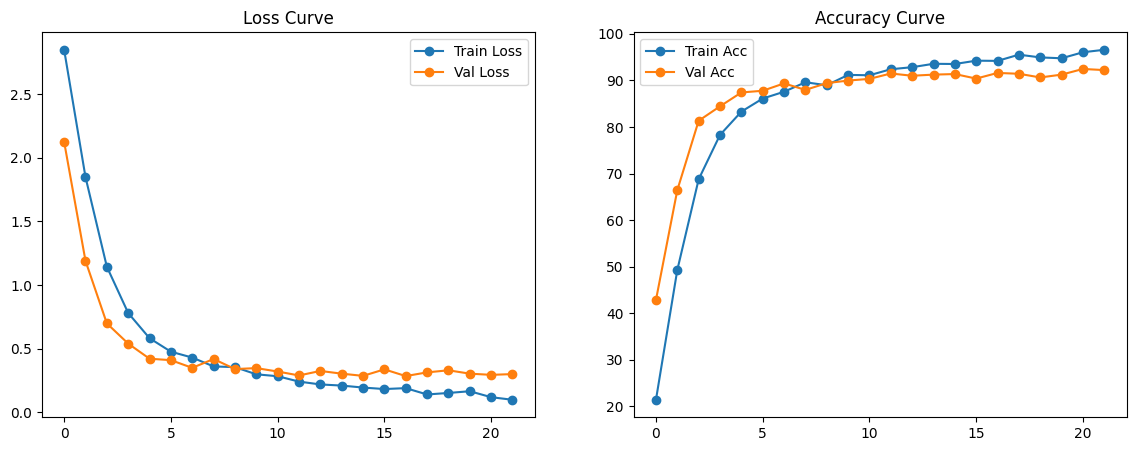

In [4]:
epochs = CONFIG["epochs"]
patience = CONFIG["patience"]

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
early_stop_counter = 0
best_model_weights = copy.deepcopy(model.state_dict())

print("Starting Advanced Training Loop...")
for epoch in range(epochs):
    start_time = time.time()
    
    # --- TRAIN ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    
    # --- VALIDATION ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total
    
    # Step the learning rate scheduler
    scheduler.step(val_loss)
    
    # Save metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{epochs} | Time: {time.time()-start_time:.1f}s | LR: {current_lr:.6f} | "
          f"Train Loss: {train_loss:.3f} Acc: {train_acc:.1f}% | Val Loss: {val_loss:.3f} Acc: {val_acc:.1f}%")
    
    # --- EARLY STOPPING LOGIC ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}! No improvement for {patience} epochs.")
            break

# Load the best weights back into the model
model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), 'OncoBridge_Phase1_Best.pth')
print("Training Complete. Best model saved.")

# --- PLOT CURVES ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='o')
axes[0].set_title('Loss Curve')
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc', marker='o')
axes[1].plot(val_accs, label='Val Acc', marker='o')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
plt.show()

Evaluating Best Model...

--- CLASSIFICATION REPORT (Validation Set) ---
                                       precision    recall  f1-score   support

                adrenocortical cancer       0.88      1.00      0.94        15
         bladder urothelial carcinoma       0.96      0.84      0.89        80
             brain lower grade glioma       1.00      1.00      1.00       102
            breast invasive carcinoma       0.97      0.97      0.97       157
       cervical & endocervical cancer       0.85      0.84      0.84        55
                   cholangiocarcinoma       0.62      0.71      0.67         7
                 colon adenocarcinoma       0.74      0.98      0.84        58
        diffuse large B-cell lymphoma       1.00      0.86      0.92         7
                 esophageal carcinoma       0.79      0.62      0.70        37
              glioblastoma multiforme       1.00      1.00      1.00        29
  head & neck squamous cell carcinoma       0.88      0.9

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


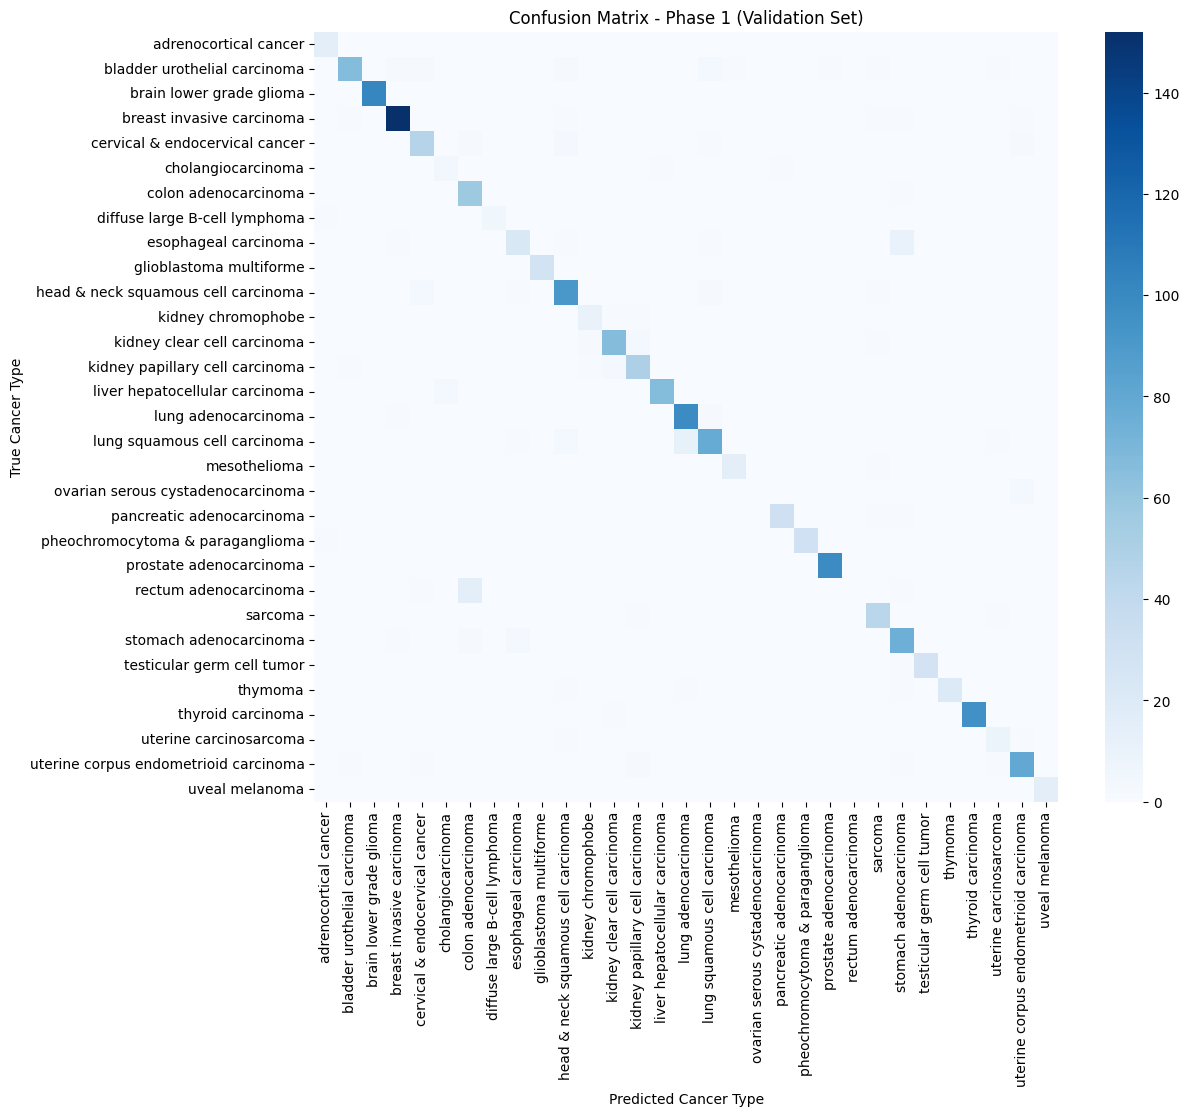

In [5]:
print("Evaluating Best Model...")
model.eval()
all_preds, all_targets = [], []

# Use test_loader if it exists, otherwise evaluate on val_loader
eval_loader = test_loader if CONFIG["use_test_set"] else val_loader
eval_name = "Test Set" if CONFIG["use_test_set"] else "Validation Set"

with torch.no_grad():
    for inputs, targets in eval_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

# Decode integers back to text names
y_true_text = le.inverse_transform(all_targets)
y_pred_text = le.inverse_transform(all_preds)

print(f"\n--- CLASSIFICATION REPORT ({eval_name}) ---")
print(classification_report(y_true_text, y_pred_text))

# Confusion Matrix
cm = confusion_matrix(y_true_text, y_pred_text)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues', fmt='g')
plt.title(f'Confusion Matrix - Phase 1 ({eval_name})')
plt.ylabel('True Cancer Type')
plt.xlabel('Predicted Cancer Type')
plt.xticks(rotation=90)
plt.show()